In [ ]:
!pip install pycocotools segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.1 MB/s eta 0:00:00


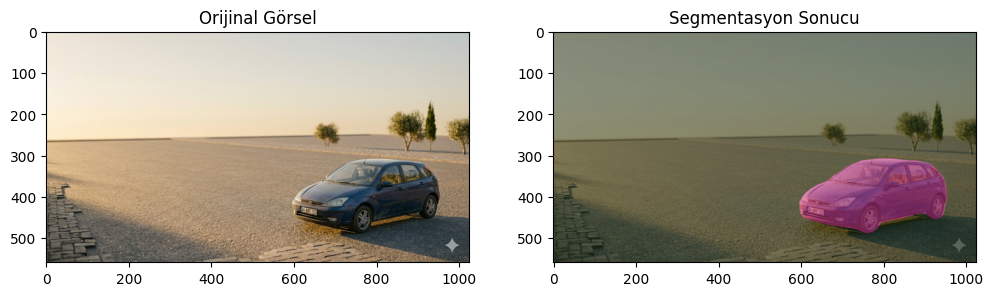

In [ ]:
import torch
import torchvision
from torchvision import transforms as T
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. COCO veri setiyle önceden eğitilmiş gerçek bir model çağır (DeepLabV3)
# Bu model 20'den fazla nesneyi (araba, köpek vb.) tanır.
model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval() # Modeli tahmin moduna aldık

# 2. Resmini modele hazırladık (Boyutlandırma ve Normalizasyon)
yol = '/content/araba.jpg'
resim = cv2.imread(yol)
resim = cv2.cvtColor(resim, cv2.COLOR_BGR2RGB)
h, w, c = resim.shape # Orijinal boyutları kaydet

transform = T.Compose([
    T.ToPILImage(),
    T.Resize(520), # Modelin beklediği boyut
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(resim).unsqueeze(0) # Modele uygun formata soktuk

# 3. YAPAY ZEKA TAHMİNİ: Model nesneleri buluyor ve pikselleri sınıflandırıyor
with torch.no_grad():
    output = model(input_tensor)['out'][0]
output_predictions = output.argmax(0).byte().cpu().numpy()

# 4. Maskeyi renklendirme (Görselleştirme)
# COCO sınıflarına göre renk haritası oluşturma
num_classes = output.shape[0]
r = np.zeros_like(output_predictions).astype(np.uint8)
g = np.zeros_like(output_predictions).astype(np.uint8)
b = np.zeros_like(output_predictions).astype(np.uint8)

for l in range(0, num_classes):
    idx = output_predictions == l
    # Rastgele renkler atıyoruz (Hangi sınıfın hangi ID olduğu)
    r[idx] = np.random.randint(0, 255)
    g[idx] = np.random.randint(0, 255)
    b[idx] = np.random.randint(0, 255)

# Oluşturulan renkli maskeyi orijinal resim boyutuna büyütüyoruz
renkli_maske = cv2.merge([r, g, b])
renkli_maske = cv2.resize(renkli_maske, (w, h), interpolation=cv2.INTER_NEAREST)

# 5. Orijinal resim ile maskeyi harmanladık
sonuc = cv2.addWeighted(resim, 0.5, renkli_maske, 0.5, 0)

# 6. Ekrana bastırdık
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Orijinal Görsel")
plt.imshow(resim)

plt.subplot(1, 2, 2)
plt.title("Segmentasyon Sonucu")
plt.imshow(sonuc)
plt.show()